In [3]:
from cirq_sic import *

## Define a sky/ground scenario

You can choose `run_type` to be `clean` (no noise), `noisy` (with hardware noise model), or `real` (on the hardware).

The optimizer can be set to `cirq` (just enough to conform to the hardware) or `bqskitn` where `n` is the level of optimization (1, 2, 3, or 4).

Right now `d` has to be a power of 2: the circuits are written for any `d`, I just need to refactor them in.

`fiducial` can be any normalized numpy vector. Make sure to give it a unique descriptive name in `fiducial_description`.

`wh_implementation` can be `simple` (just one ancilla) or `ak` (full Arthurs-Kelly with two ancillae).

`get_wh_qubits` will pick qubits for you (right now it always picks them same).

In [4]:
d = 2
wh_implementation = "ak"
specs = {"dataset_id": "test",
         "processor_id": "willow_pink",
         "run_type": "clean",
         "qubits": get_wh_qubits(d, wh_implementation),
         "n_shots": 50000,
         "optimizer": "cirq",
         "d": d,
         "fiducial": load_sic_fiducial(d),
         "fiducial_description": "numerical_sic",
         "wh_implementation": wh_implementation}

## Run them all!

`task_from_specs` builds a task specifying each experiment. Right now there are: `CharacterizeWHReferenceDeviceTask`, `WHPOVMOnBasisStatesTask`, `BasisMeasurementOnWHStatesTask`, `BasisMeasurementOnBasisStatesTask`, and `BasisMeasurementAfterWHPOVMOnBasisStatesTask`.

`run_sky_ground_task` actually runs a given task. It first builds the circuits, optimizes them, runs the circuits in batch, and post-processes the data.

The data is saved in a directory stucture under `base_dir`. For example, the specs above generate

`test/d2/CharacterizeWHReferenceDeviceTask/ak/numerical_sic/cirq_clean_n50k_willow_pink_q4_2-5_2-6_2.json`

which contains the post-processed data. The folder `test/d2/CharacterizeWHReferenceDeviceTask/ak/numerical_sic/` will also contain a log file `experiment.log` and a subfolder `circuits` which has the raw and optimized circuits as json files. 

In [12]:
base_dir = "data"

for task_type in sk_ground_tasks:
    task = task_from_specs(task_type, specs)
    run_sky_ground_task(task)

2025-10-23 22:42:36 [INFO] test/d2/CharacterizeWHReferenceDeviceTask/ak/numerical_sic/cirq_clean_n50k_willow_pink_q4_2-5_2-6_2: Task already exists. Skipping.
2025-10-23 22:42:36 [INFO] test/d2/WHPOVMOnBasisStatesTask/ak/numerical_sic/cirq_clean_n50k_willow_pink_q4_2-5_2-6_2: Task already exists. Skipping.
2025-10-23 22:42:36 [INFO] test/d2/BasisMeasurementOnWHStatesTask/numerical_sic/cirq_clean_n50k_willow_pink_q4_2-5_2-6_2: Task already exists. Skipping.
2025-10-23 22:42:36 [INFO] test/d2/BasisMeasurementOnBasisStatesTask/cirq_clean_n50k_willow_pink_q4_2-5_2-6_2: Task already exists. Skipping.
2025-10-23 22:42:36 [INFO] test/d2/BasisMeasurementAfterWHPOVMOnBasisStatesTask/numerical_sic/cirq_clean_n50k_willow_pink_q4_2-5_2-6_2: Task already exists. Skipping.


## Double checking

We can test that things are working correctly. 

`load_sky_ground_results` takes specs and if `separate=True` returns the tasks objects and a dictionary containing the post-processed results, that is, the matrices $P$, $r$, $C$, $q$, and $p$ which should satisfy the relations

\begin{align}
C P^{-1} r = q && C r = p.
\end{align}

`exactify(task)` returns the exact (not simulated) probabilities for a task. The code below manually calculates the correct probabilities, compares it to the output of `exactify` (to check if the circuit is correct), and then makes sure that the empirical results aren't too far off (they probably are).

In [13]:
tol = 1e-1
tasks, sg_results = load_sky_ground_results(specs, separate=True, base_dir=base_dir)

task = tasks[CharacterizeWHReferenceDeviceTask]
E = wh_povm(np.array(task.fiducial))
P = np.array([[(a@b).trace()/b.trace() for b in E] for a in E]).real
assert np.allclose(P, exactify(task)["P"])
assert np.linalg.norm(sg_results["P"] - P) < tol

task = tasks[WHPOVMOnBasisStatesTask]
E = wh_povm(np.array(task.fiducial))
Pi = [np.diag(np.eye(task.d)[i]) for i in range(task.d)]
r = np.array([[(a@b).trace() for b in Pi] for a in E]).real
assert np.allclose(r, exactify(task)["r"])
assert np.linalg.norm(sg_results["r"] - r) < tol

task = tasks[BasisMeasurementOnWHStatesTask]
E = wh_povm(np.array(task.fiducial))
Pi = [np.diag(np.eye(task.d)[i]) for i in range(task.d)]
C = np.array([[(a@b).trace()/b.trace() for b in E] for a in Pi]).real
assert np.allclose(C, exactify(task)["C"])
assert np.linalg.norm(sg_results["C"] - C) < tol

task = tasks[BasisMeasurementOnBasisStatesTask]
q = np.eye(task.d)
assert np.allclose(q, exactify(task)["q"])
assert np.linalg.norm(sg_results["q"] - q) < tol

task = tasks[BasisMeasurementAfterWHPOVMOnBasisStatesTask]
E = wh_povm(np.array(task.fiducial))
Pi = [np.diag(np.eye(task.d)[i]) for i in range(task.d)]
post_measurement = np.array([sum([(a@b).trace()*b/b.trace() for b in E]) for a in Pi]).real
p = np.array([[(pi @ rho).trace() for pi in Pi] for rho in post_measurement])
assert np.allclose(p, exactify(task)["p"])
assert np.linalg.norm(sg_results["p"] - p) < tol

## Metrics

`sky_ground_metrics` takes specs, loads up the results, and calculates all the errors we might be interested in.

In [16]:
sky_ground_metrics(specs, base_dir=base_dir)

{'P_err': np.float64(0.005253868959618645),
 'Phi_err': np.float64(0.04543305424877198),
 'rel_quantumness': np.float64(0.994778057556278),
 'q_err': np.float64(0.0),
 'born_rule_err': np.float64(0.004788458762358623),
 'p_err': np.float64(0.0034102177771161476),
 'LTP_err': np.float64(0.003396122190706773)}

We can see visually how we are doing with `sky_ground_images`, which saves the resulting plots to `img_path`.

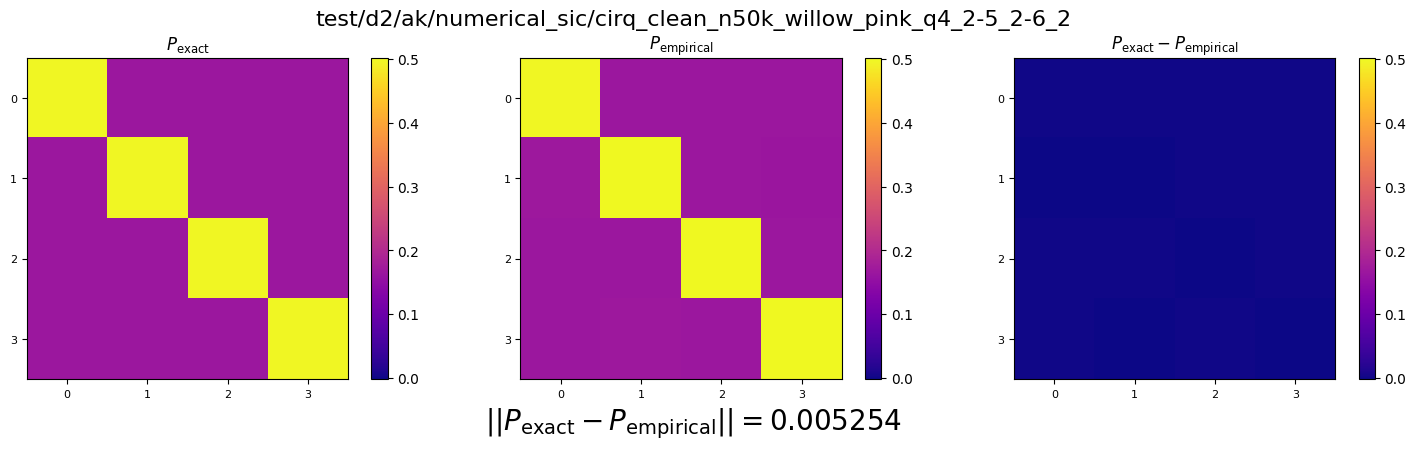

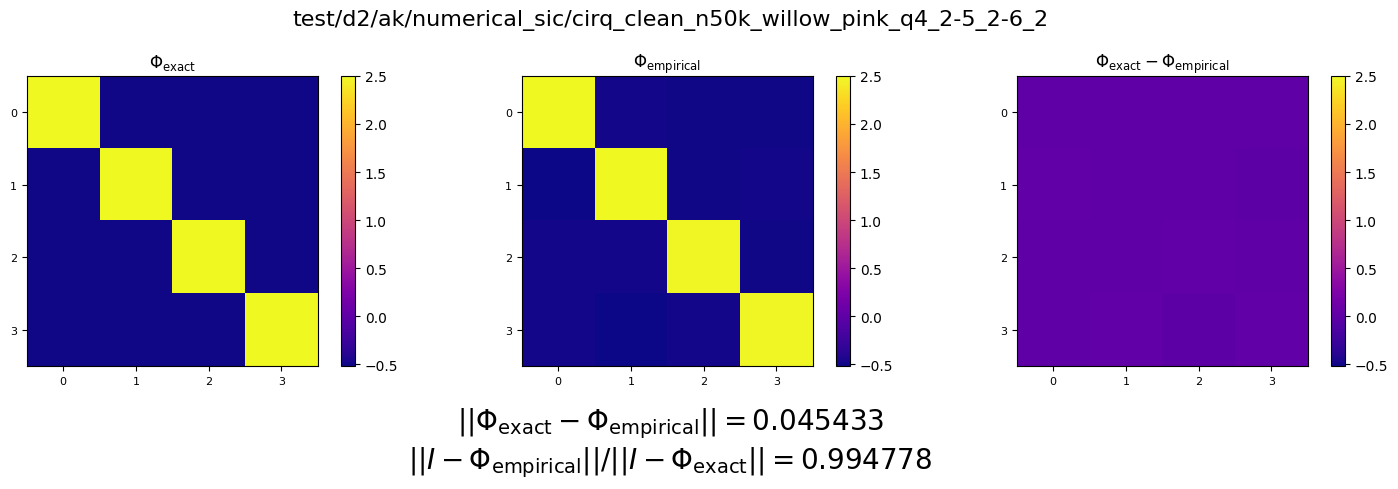

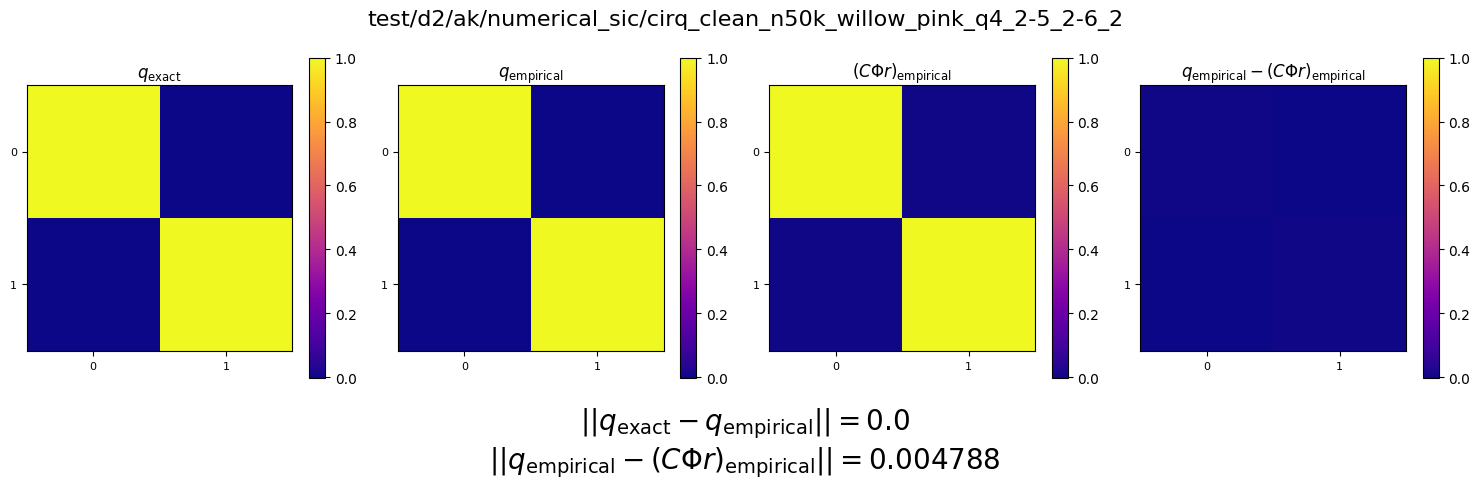

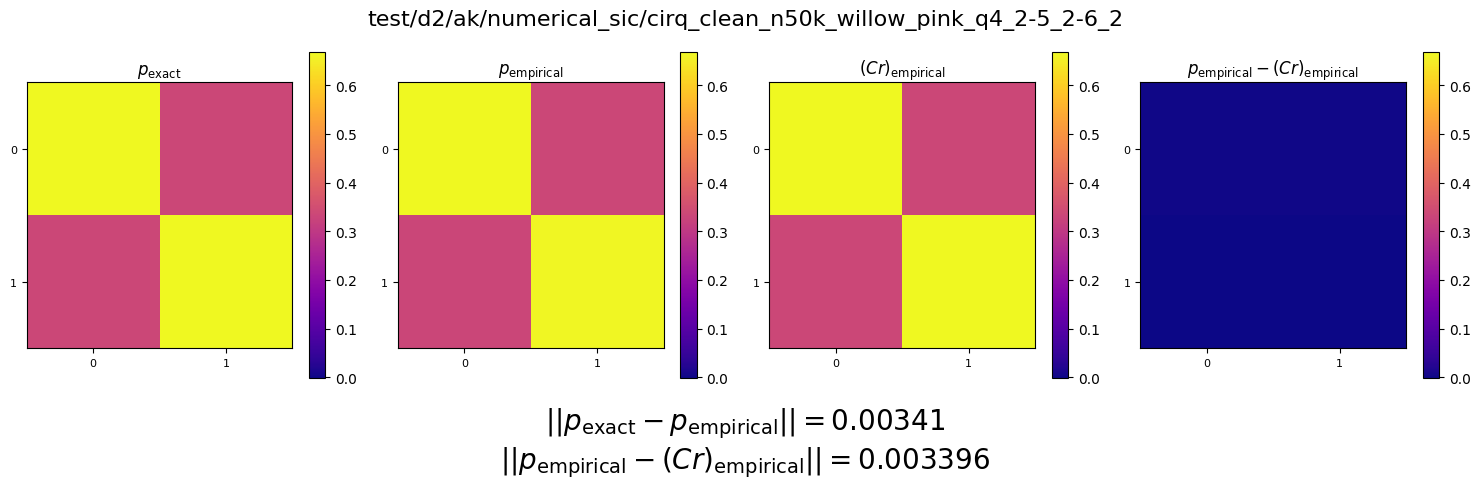

In [8]:
sky_ground_images(specs, img_path="img")